## Random Forest (Rastgele Orman) Nedir? 

Random Forest, makine öğrenmesinde sıklıkla kullanılan ve ensemble (topluluk) yöntemlerinin önemli bir temsilcisidir. Temel amacı, birden fazla karar ağacını farklı veri ve değişken altkümeleriyle eğitip bunların sonuçlarını birleştirerek daha güvenilir ve doğru tahminler sunmaktır.

---

### 1. Karar Ağacı (Decision Tree) Nedir?

Karar ağacı modelleri, verideki örnekleri dallar halinde belirli koşullara (örneğin "Yaşı > 30 mu?") ayırarak sınıflandırır ya da tahmin eder. Her düğümde veriyi bölmek için bir değişken seçilir; en iyi bölen değişken ise genellikle bilgi kazancı (information gain) veya Gini gibi kriterlerle belirlenir.


Karar ağacı yapısında yukarıdan aşağıya dallanarak ve her dalda belirli bir özelliğe göre soru sorularak nihai karar veya tahmin yapılır.

---

### 2. Random Forest’ın Yapısı ve Çalışma Prensibi

- Random Forest, **Bagging (Bootstrap Aggregating)** ve **Random Subspace** tekniklerinin birleşimidir.
- Her bir ağaç, eğitim verisinin rastgele ve tekrarlamalı olarak seçilmiş (bootstrap) bir alt kümesi üzerinde oluşturulur.
- Her bir ağacın her düğümünde en iyi dallara ayırıcı (bilgi kazancı) değişken, tüm değişkenler arasından değil, rastgele seçilen daha az sayıdaki değişken arasından belirlenir (**random subspace yöntemi**).
- Böylece her ağaç farklı veri ve değişken altkümesiyle eğitilir ve model çeşitliliği artar.
- Tahmin yapılırken tüm ağaçların çıktısı birleştirilir; sınıflandırma problemlerinde çoğunluk oyu (majority voting), regresyon problemlerinde ise ortalama alınır.

> Klasik bir karar ağacında her düğümde bölme işlemi için TÜM değişkenler değerlendirilirken, Random Forest’ta her düğümde yalnızca rastgele seçilen daha az sayıdaki değişken dikkate alınır.

---

### 3. Teorik Arka Plan

- Bagging (Breiman, 1996) ile bootstrap (rastgele ve tekrarlı örnek seçim) kullanılır.
- Random Subspace (Ho, 1998) ile ağaçlarda kullanılan özelliklerin bir alt kümesi rastgele olarak alt uzaydan seçilir.
- Her karar ağacı hem farklı örneklerle hem de farklı değişkenlerle eğitilerek modelin varyansı düşürülür ve genellenebilirliği artırılır.

---

### 4. Günlük Hayattan Benzerlik

- Bir konu hakkında karar verirken sadece bir kişiye danışmak yerine, birçok kişiden rastgele fikir almak ve nihai kararı çoğunluğun görüşüne göre vermek gibidir.

---

### 5. Avantajları

- **Daha doğru ve güvenilir tahminler** yapar.
- Yanlışlardan kaçınmak ve aşırı öğrenmeyi (overfitting) azaltmak için tasarlanmıştır.
- Çeşitliliği sayesinde tek bir karara bağlı kalmaz ve daha istikrarlı sonuçlar üretir.
- Kullanımı ve uygulanması görece kolaydır.

---

### 6. Sonuç

Random Forest, birden fazla karar ağacının ortak kararına göre çalışan; güçlü, esnek ve güvenilir bir makine öğrenmesi yöntemidir. Büyük veri ve karmaşık problemlerde sıkça tercih edilir.
```

In [1]:
# Adım adım Random Forest ve diğer topluluk algoritmalarına giriş için gerekli kütüphaneleri ve veriyi hazırlayalım:

# 1. Uyarıları göz ardı etmek için gerekli kütüphaneyi içe aktaralım:
import warnings

# 2. Temel veri işleme ve sayısal işlemler için pandas ve numpy'ı içe aktaralım:
import numpy as np
import pandas as pd

# 3. Görselleştirme için seaborn ve matplotlib kütüphanelerini ekleyelim:
import seaborn as sns
from matplotlib import pyplot as plt

# 4. Makine öğrenmesi modelleri ve modelleme araçları için sklearn içerisinden gerekli sınıfları ekleyelim:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, RandomizedSearchCV, validation_curve

# 5. Gelişmiş topluluk yöntemleri için ek kütüphaneleri ekleyelim:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 6. Eğer yukarıdaki gelişmiş kütüphaneler yüklü değilse aşağıdaki pip komutları ile yükleyebilirsiniz:
# !pip install catboost
# !pip install xgboost
# !pip install lightgbm

# 7. Pandas ile çıktıların daha okunabilir olması için görüntüleme ayarlarını yapalım:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

# 8. Ortaya çıkan uyarı mesajlarını görmemek için warnings kullanarak filtre uygulayalım:
warnings.simplefilter(action='ignore', category=Warning)

# 9. Çalışacağımız veri setini pandas ile yükleyelim:
df = pd.read_csv("datasets/diabetes.csv")

# 10. Veri setinde hedef değişkeni ('Outcome') ayıralım ve girdilerden çıkaralım:
y = df["Outcome"]                       # Bağımlı değişken (etiket)
X = df.drop(["Outcome"], axis=1)        # Bağımsız değişkenler (girdiler)

In [2]:
# RandomForestClassifier modelini oluşturuyoruz ve rastgelelik kontrolü için random_state parametresini 46 olarak ayarlıyoruz.
rf_model = RandomForestClassifier(random_state=46)
rf_model.fit(X, y)  # Modeli bağımsız değişkenler (X) ve target (y) ile eğitiyoruz.

# Modelin tüm hiperparametrelerini ve ayarlarını görebilmek için get_params() fonksiyonunu kullanıyoruz. 
# Bu fonksiyon modelde kullanılabilir ve değiştirilebilir tüm parametreleri bir sözlük (dict) olarak döndürür.
params = rf_model.get_params()
print(params)

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 46, 'verbose': 0, 'warm_start': False}


In [3]:
# Modelimizin başarımını değerlendirmek için çapraz doğrulama (cross validation) kullanacağız.
# cross_validate fonksiyonu ile modeli 10 katlı (cv=10) olarak farklı metrikler kullanarak (accuracy, f1, roc_auc) test edeceğiz.
cv_results = cross_validate(
    estimator=rf_model,   # Kullanılacak model
    X=X,                  # Bağımsız değişkenler (özellikler)
    y=y,                  # Bağımlı değişken (hedef/etiket)
    cv=10,                # 10 katlı çapraz doğrulama
    scoring=["accuracy", "f1", "roc_auc"]  # Kullanılacak metrikler
)

# Her bir metrik için 10 doğrulamadan çıkan skorların ortalamasını ayrı ayrı hesaplayıp yazdıralım.
accuracy_mean = cv_results['test_accuracy'].mean()   # Doğruluk ortalaması
f1_mean = cv_results['test_f1'].mean()               # F1 skoru ortalaması
roc_auc_mean = cv_results['test_roc_auc'].mean()     # ROC AUC ortalaması

print("Ortalama Doğruluk (Accuracy):", accuracy_mean)
print("Ortalama F1 Skoru:", f1_mean)
print("Ortalama ROC AUC:", roc_auc_mean)

Ortalama Doğruluk (Accuracy): 0.7591079972658921
Ortalama F1 Skoru: 0.6165239982629569
Ortalama ROC AUC: 0.830088319088319


In [4]:
# Şimdi modelimizi daha iyi hale getirmek için bazı ayarları deneyeceğiz. Bunlara hiperparametre ayarlama (veya hiperparametre optimizasyonu) denir.
# Burada birçok farklı parametre kombinasyonunu otomatik olarak deneriz ve en iyi sonucu bulmak için GridSearchCV adlı aracı kullanırız.

# Önce hangi değerleri denemek istediğimizi bir sözlük (dict) içinde belirtiyoruz.
# - max_depth: Ağacın maksimum derinliği (dallanma seviyesi). Daha düşük değerler aşırı öğrenmeyi engeller.
# - max_features: Her bir ağaç için seçim sırasında kullanılacak özellik (değişken) sayısı.
# - min_samples_split: Bir dalı bölmek için gereken minimum örnek (veri) sayısı.
# - n_estimators: Ormanda oluşturulacak ağaç (decision tree) sayısı.

rf_params = {
    "max_depth": [5, 8, None],
    "max_features": [3, 5, 7, "auto"],
    "min_samples_split": [2, 5, 8, 15, 20],
    "n_estimators": [100, 200, 500]
}

# Şimdi GridSearchCV ile bu parametre kombinasyonlarının hepsini deneyeceğiz.
# cv=5 demek, veriyi 5 parçaya böleceğimiz ve her birinde modeli deneyeceğimiz anlamına gelir (5 katlı çapraz doğrulama).
# n_jobs=-1 ise, işlemler bütün işlemci çekirdeklerinde paralel çalışır, bunu hızlı yapar.
# verbose=True açıklama mesajları basar, takip etmemiz kolay olur.

grid_search = GridSearchCV(
    estimator=rf_model,        # Kullanmak istediğimiz model
    param_grid=rf_params,      # Denenecek parametreler
    cv=5,                      # 5 katlı çapraz doğrulama
    n_jobs=-1,                 # Tüm çekirdekleri kullan (hızlı)
    verbose=True               # Ekrana ilerleme mesajları yazdır
)
# Şimdi, eğitim verimiz X ve etiketlerimiz y ile aramayı başlatıyoruz.
grid_search.fit(X, y)

# En iyi bulunan parametre kombinasyonunu ekrana yazdıralım:
print("En iyi hiperparametreler:", grid_search.best_params_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


En iyi hiperparametreler: {'max_depth': 5, 'max_features': 3, 'min_samples_split': 2, 'n_estimators': 100}


In [5]:
# 1. En iyi bulunan hiperparametrelerle modelimizi güncelliyoruz ve eğitiyoruz.
rf_final = rf_model.set_params(**grid_search.best_params_, random_state=17)  # GridSearch'ten en iyi parametreleri al
rf_final.fit(X, y)  # Modeli tüm veriyle tekrar eğit

# 2. Güncellenmiş modelimizin genel başarısını değerlendirmek için tekrar çapraz doğrulama uygulayalım.
cv_results = cross_validate(
    rf_final,                         # eğitilmiş final model
    X, y,                             # özellikler ve hedef değişken
    cv=10,                            # 10 katlı çapraz doğrulama
    scoring=["accuracy", "f1", "roc_auc"] # üç farklı başarı metriği ile
)

# 3. Her bir metriğin ortalama değerini ayrı ayrı hesaplayıp yazdıralım:
accuracy_mean = cv_results['test_accuracy'].mean()
f1_mean = cv_results['test_f1'].mean()
roc_auc_mean = cv_results['test_roc_auc'].mean()

print("Tuned Model Ortalama Doğruluk (Accuracy):", accuracy_mean)
print("Tuned Model Ortalama F1 Skoru:", f1_mean)
print("Tuned Model Ortalama ROC AUC:", roc_auc_mean)

Tuned Model Ortalama Doğruluk (Accuracy): 0.762987012987013
Tuned Model Ortalama F1 Skoru: 0.622043182596006
Tuned Model Ortalama ROC AUC: 0.8355783475783476


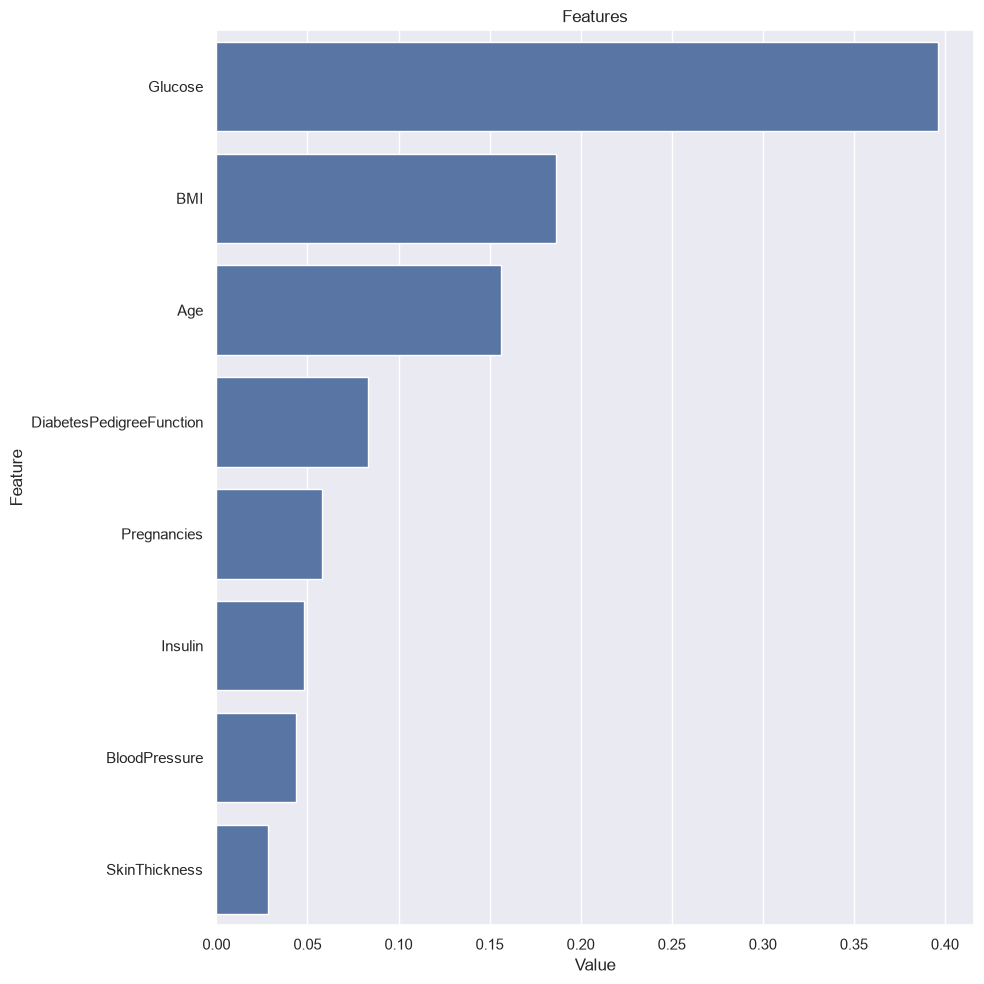

In [6]:

def plot_importance(model, features, num=len(X), save=False):
    # 1. model.feature_importances_ ile modelin her bir özelliğe (feature) verdiği önemi alıyoruz.
    #    features.columns ise, özellik isimlerini getiriyor.
    #    Bu ikisini bir DataFrame içinde birleştiriyoruz.
    feature_imp = pd.DataFrame({
        'Value': model.feature_importances_, 
        'Feature': features.columns
    })

    # 2. Grafik çizimi için bir pencere açıyoruz (boyutu 10x10).
    plt.figure(figsize=(10, 10))
    # 3. Seaborn kütüphanesinin yazı ölçeğini (font_scale) 1 olarak ayarlıyoruz.
    sns.set(font_scale=1)

    # 4. Özelliklerin önem değerine göre,
    #    en yüksek değerden en düşüğe sıralayıp (ascending=False),
    #    sadece ilk 'num' tanesini alıyoruz.
    #    Sonra yatay bir barplot çiziyoruz: x ekseninde önem değeri, y ekseninde özellik ismi.
    sns.barplot(
        x="Value",
        y="Feature",
        data=feature_imp.sort_values(by="Value", ascending=False)[0:num]
    )

    # 5. Grafik başlığını 'Features' olarak ayarlıyoruz.
    plt.title('Features')

    # 6. Grafik içeriğinin pencereye iyi oturmasını sağlıyoruz.
    plt.tight_layout()

    # 7. Grafiği gösteriyoruz.
    plt.show()

    # 8. Eğer fonksiyon çağrılırken save=True kullanılırsa,
    #    grafiği 'importances.png' adıyla kaydediyoruz.
    if save:
        plt.savefig('importances.png')

# Bu fonksiyonu, random forest sonucunuz olan rf_final modeli ve veri setinizin X özellikleriyle çağırıyoruz.
plot_importance(rf_final, X)


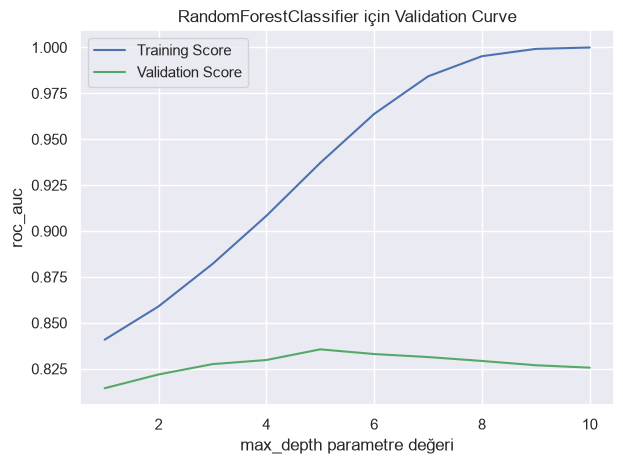

In [7]:

def val_curve_params(model, X, y, param_name, param_range, scoring="roc_auc", cv=10):
    """
    Bir modelin bir hiperparametresi için validation curve (doğrulama eğrisi) çizer.
    Adım adım:
    
    1. model: Kullanmak istediğimiz makine öğrenmesi algoritması. (Örneğin RandomForest)
    2. X: Özellikler (bağımsız değişkenler)
    3. y: Hedef (bağımlı değişken)
    4. param_name: İncelenecek hiperparametrenin ismi (örn. 'max_depth')
    5. param_range: Bu hiperparametrenin alacağı değerler aralığı (örn. range(1, 11))
    6. scoring: Modeli değerlendirme metriği (varsayılan: "roc_auc")
    7. cv: Kaç katlı çapraz doğrulama yapılacağı (varsayılan: 10)
    """

    # 1. validation_curve fonksiyonu, verilen parametre aralığında;
    #    hem eğitim verisinde hem doğrulama verisinde modelin başarısını (skorunu) hesaplar.
    #    Çıktısı: eğitim ve doğrulama skorlarının 2 boyutlu dizisi
    train_score, test_score = validation_curve(
        model,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        scoring=scoring,
        cv=cv
    )

    # 2. Her parametre değeri için ortalama eğitim skoru hesaplanır.
    mean_train_score = np.mean(train_score, axis=1)
    # 3. Her parametre değeri için ortalama doğrulama skoru hesaplanır.
    mean_test_score = np.mean(test_score, axis=1)

    # 4. Ort. eğitim skorlarını parametre aralığına göre grafikte mavi olarak çiz.
    plt.plot(param_range, mean_train_score, label="Training Score", color='b')
    # 5. Ort. doğrulama skorlarını parametre aralığına göre grafikte yeşil olarak çiz.
    plt.plot(param_range, mean_test_score, label="Validation Score", color='g')

    # 6. Grafiğe başlık ekle: Hangi model için olduğunu belirt.
    plt.title(f"{type(model).__name__} için Validation Curve")
    # 7. Yatay eksen: Hangi parametreyi incelediğimizi belirt.
    plt.xlabel(f"{param_name} parametre değeri")
    # 8. Dikey eksen: Kullanılan skor türü.
    plt.ylabel(f"{scoring}")
    # 9. Grafik düzgün görünsün diye.
    plt.tight_layout()
    # 10. Açıklama kutusunu grafiğe ekle.
    plt.legend(loc='best')
    # 11. Grafiği göster.
    plt.show(block=True)

# Şimdi bu fonksiyonu örnek olarak,
# Random Forest modelimizin (rf_final) 'max_depth' parametresinin 1'den 10'a kadar
# nasıl etki ettiğini görmek için çağıralım:
val_curve_params(rf_final, X, y, "max_depth", range(1, 11), scoring="roc_auc")

## Gradient Boosting Machines (GBM) ve AdaBoost

Boosting yöntemleri, basit (zayıf) modelleri sırayla kurup birleştirerek karmaşık ve güçlü modeller oluşturur. Genellikle karar ağaçları kullanılır. Amaç, bir önceki modelin yapamadığı yerlerde yeni modeli başarılı kılarak toplam hatayı azaltmaktır.

---

### AdaBoost (Adaptive Boosting)

- AdaBoost, öncelikle veriye küçük bir karar ağacı uygular.
- Modelle yanlış tahmin edilen örneklere daha fazla ağırlık verilir.
- Sonraki model bu "zor" örneklere odaklanır.
- Her yeni model, toplamda en çok hata yapılan yerlere odaklanır ve art arda bu şekilde ilerler.
- En sonunda tüm modellerin kararları akıllıca birleştirilir.

**Basit bir benzetme:** 
Bir denemede hata yaptığında, bir sonraki tekrarında sadece o kısımlara ekstra çalışırsın. AdaBoost da devamlı en zorlu noktalar üzerinde kendini güçlendirir.

---

### Gradient Boosting Machines (GBM)

- GBM, hata yapan örneklere değil, yapılan hataların miktarını "gradyan" mantığıyla azaltarak çalışır.
- İlk ağaç modeli oluşturur, ardından modelin hatalarını (residuals) çıkarır.
- Yeni eklenen her ağaç, önceki ağaçların yapamadığı hataları azaltmaya çalışır.
- Böylece hata adım adım küçülür ve model her adımda daha isabetli hale gelir.

**Basit bir benzetme:** 
Ok atarken ilk seferde hedefi biraz ıskaladığını fark edersin. İkinci atışta, saptığın yönde düzeltme yaparsın. Her atışta hatanı daha da azaltırsın. GBM de aynen böyle, isabeti adım adım artırır.

---

### AdaBoost ve GBM Arasındaki Temel Farklar

- AdaBoost, yanlış tahmin edilen örneklere ağırlık vererek bunları düzeltmeye çalışır.
- GBM, hatanın miktarına odaklanır ve bu hatayı aşamalı olarak en aza indirir.
- GBM, farklı hata (kayıp) fonksiyonlarıyla daha esnek şekilde kullanılabilir.

---

### Neden GBM ve AdaBoost Kullanılır?

- Tek bir karar ağacından çok daha güçlü, esnek ve genelleyici modeller sağlarlar.
- Gerçek hayatta kredi kartı dolandırıcılığı, müşteri kaybı gibi birçok zorlu sınıflandırma problemlerinde mükemmel sonuçlar verirler.
- Bu yöntemler, XGBoost, LightGBM, CatBoost gibi popüler modern algoritmaların da temelini oluşturur.

Boosting yöntemleri, öğrenmeyi bir yolculuk gibi adım adım geliştirir ve her durakta bir öncekinden daha iyisini ortaya koymaya çalışır.

In [8]:
# GradientBoostingClassifier ile bir model oluşturduk:
gbm_model = GradientBoostingClassifier(random_state=17)

# get_params() fonksiyonu, bu modelin sahip olduğu tüm ayar parametrelerini ve değerlerini gösterir.
# Yani, model yapılandırılırken hangi seçenekler ile oluşturulmuş onları görebiliriz.
gbm_model.get_params()


{'ccp_alpha': 0.0,
 'criterion': 'deprecated',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 17,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [9]:
# Bir makine öğrenmesi modelinin gerçekten iyi çalışıp çalışmadığını anlamak için "çapraz doğrulama" (cross validation) isimli bir yöntemden yararlanırız.
# Bu yöntem, verimizi örneğin 5 parçaya böler. Sonra model her seferinde bir parçayı "test" için ayırarak kalan 4 parça üzerinde eğitilir.
# Böylece modelin başarısı tesadüf müdür yoksa genelde geçerli mi daha doğru görebiliriz.

# Aşağıda, daha önce oluşturduğumuz GBM modeli için bu işlemi yapıyoruz:
cv_results = cross_validate(
    gbm_model,                      # Kullanılacak model
    X,                              # Özellikler (bağımsız değişkenler)
    y,                              # Hedef değişken (tahmin edilecek değer)
    cv=5,                           # Veriyi 5 parçaya böl (5-katlı çapraz doğrulama)
    scoring=["accuracy", "f1", "roc_auc"]  # Ölçümler: Doğruluk, F1 ve ROC AUC skorları
)

# Sonuçlar bize 5 farklı değer olarak geliyor (çünkü 5 kat repeat edildi).
# Bunların ortalamasını alırsak modelimizin genel başarısı hakkında fikir sahibi oluruz:

print("Doğruluk (Accuracy) ortalaması:", cv_results['test_accuracy'].mean())
print("F1 skoru ortalaması:", cv_results['test_f1'].mean())
print("ROC AUC ortalaması:", cv_results['test_roc_auc'].mean())


Doğruluk (Accuracy) ortalaması: 0.7604702487055428
F1 skoru ortalaması: 0.63542546194327
ROC AUC ortalaması: 0.8269129979035638


In [10]:
# 1. Öncelikle, test etmek istediğimiz parametreleri ve bunların denenecek değerlerini bir sözlük (dict) halinde hazırlıyoruz:
gbm_params = {
    "learning_rate": [0.01, 0.1],        # Öğrenme oranı için iki değer denenecek
    "max_depth": [3, 8, 10],             # Maksimum ağaç derinliği için üç değer denenecek
    "n_estimators": [100, 500, 1000],    # Toplam ağaç sayısı için üç değer denenecek
    "subsample": [1, 0.5, 0.7]           # Alt örnekleme oranı için üç değer denenecek
}

# 2. Şimdi GridSearchCV ile en iyi parametreleri arayacağız.
#    - Burada `gbm_model` bizim modelimiz,
#    - `gbm_params` ise denenecek parametreler,
#    - `cv=5` ile 5 katlı çapraz doğrulama yapılacak,
#    - `n_jobs=-1` tüm işlemciler kullanılsın demek,
#    - `verbose=True` arama sürecinde bilgi mesajları gösterir.

gbm_best_grid = GridSearchCV(
    estimator=gbm_model,
    param_grid=gbm_params,
    cv=5,
    n_jobs=-1,
    verbose=True
)

# 3. GridSearchCV nesnesini tüm verimizle eğitiyoruz:
gbm_best_grid.fit(X, y)

# 4. Sonuçta en iyi kombinasyonlar aşağıdaki gibi elde edilir:
print("En iyi parametreler:", gbm_best_grid.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
En iyi parametreler: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7}


In [11]:
# 1. GridSearchCV ile bulduğumuz en iyi parametreleri orijinal modelimize atıyoruz.
gbm_final = gbm_model.set_params(**gbm_best_grid.best_params_, random_state=17)

# 2. Bu yeni modelimizi (en iyi parametrelerle) tüm verimize fit (eğit) ediyoruz.
gbm_final.fit(X, y)

# 3. Modelin başarısını değerlendirmek için 5 katlı çapraz doğrulama uyguluyoruz.
cv_results = cross_validate(
    gbm_final,                  # En iyi parametrelerle eğitilmiş model
    X,                          # Özellikler
    y,                          # Hedef değişken
    cv=5,                       # 5 katlı çapraz doğrulama
    scoring=["accuracy", "f1", "roc_auc"] # Değerlendirilecek skorlar
)

# 4. Elde edilen sonuçların ortalamasını alıyoruz (her biri 5 kat sonucu)
print("Doğruluk (Accuracy) ortalaması:", cv_results['test_accuracy'].mean())
print("F1 skoru ortalaması:", cv_results['test_f1'].mean())
print("ROC AUC ortalaması:", cv_results['test_roc_auc'].mean())


Doğruluk (Accuracy) ortalaması: 0.7760886172650878
F1 skoru ortalaması: 0.6647146517411393
ROC AUC ortalaması: 0.8347190775681342


## XGBoost (Extreme Gradient Boosting) Nedir?  

XGBoost, "Extreme Gradient Boosting" isminin kısaltmasıdır ve doğruluk, hıza ve verimliliğe odaklanan, popüler bir boosting (arttırmalı topluluk) algoritmasıdır. Karar ağaçlarını toplu olarak (ensemble) kullanarak tahmin gücünü artırır ve Kaggle gibi yarışmalarda sıkça tercih edilir.  

---

### XGBoost’un Temel Özellikleri

- **Boosting Yöntemi:** Her yeni ağaç, önceki ağaçların hatalarını düzeltmeyi amaçlayacak şekilde eklenir.
- **Düzenlileştirme (Regularization):** Model karmaşıklığını kontrol ederek aşırı öğrenmeyi (overfitting) engeller.
- **Verimlilik:** Paralel işlem (parallelization) ve optimize edilmiş veri yapıları sayesinde çok hızlı çalışır.
- **Eksik Veri Desteği:** Eksik değerlere karşı oldukça dayanıklıdır ve kendisi işleyebilir.
- **Erken Durdurma:** Modeli gereğinden fazla eğitmeyerek eğitim sürecini otomatik olarak sonlandırabilir.

---

## XGBoost’un Avantajları  
- Büyük ve karmaşık veri setlerinde yüksek performans.
- Eksik değerlerle doğrudan çalışabilme.
- Düzenlileştirme sayesinde overfitting riskinin azaltılması.
- GPU desteğiyle çok hızlı eğitim (kütüphanenin uygun kurulumu ile).
- Özellik önem düzeylerini hızlıca inceleyebilme.

---

### XGBoost ile İlgili Yararlı Parametreler

- `learning_rate` : Her adımda ağırlıklandırma oranı
- `max_depth` : Her ağaç için en fazla derinlik
- `n_estimators` : Ağaç sayısı
- `subsample` : Her iterasyonda kullanılacak örnek oranı
- `colsample_bytree` : Her ağaç için kullanılacak sütun oranı
- `gamma`, `lambda`, `alpha` : Düzenlileştirme parametreleri

---

**Not:** XGBoost, hem sınıflandırma hem de regresyon problemlerinde kullanılabilir.

In [12]:
# 1. XGBoost modellerini kullanmak için gerekli kütüphaneyi ve modeli çağırıyoruz.
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, GridSearchCV

# 2. Modelimizi ilk olarak varsayılan (default) parametrelerle oluşturuyoruz.
xgboost_model = XGBClassifier(random_state=17, use_label_encoder=False)

# 3. Mevcut parametreleri görmek için get_params fonksiyonunu kullanabiliriz.
print("XGBoost Varsayılan Parametreleri:", xgboost_model.get_params())

# 4. Modelimizin temel (tune edilmemiş) halini 5 katlı çapraz doğrulama ile test ediyoruz.
cv_results = cross_validate(xgboost_model, X, y, cv=5, scoring=["accuracy", "f1", "roc_auc"])

# 5. Her bir metriğin ortalamasını yazdıralım:
print("Başlangıç Doğruluk (Accuracy) Ortalaması:", cv_results['test_accuracy'].mean())
print("Başlangıç F1 Skoru Ortalaması:", cv_results['test_f1'].mean())
print("Başlangıç ROC AUC Ortalaması:", cv_results['test_roc_auc'].mean())

# 6. Şimdi modelimizin performansını artırmak için en önemli parametrelerden birkaçını arayacağız.
xgboost_params = {
    "learning_rate": [0.1, 0.01],            # Öğrenme oranı
    "max_depth": [5, 8],                     # Ağaçların maksimum derinliği
    "n_estimators": [100, 500, 1000],        # Toplam ağaç sayısı
    "colsample_bytree": [0.7, 1]             # Her ağaçta kullanılacak sütun oranı
}

# 7. En iyi parametreleri bulmak için GridSearchCV ile tarama yapıyoruz.
xgboost_best_grid = GridSearchCV(
    estimator=xgboost_model,
    param_grid=xgboost_params,
    cv=5,
    n_jobs=-1,
    verbose=True
).fit(X, y)

# 8. Bulunan en iyi parametrelerle modeli tekrar eğitiyoruz.
xgboost_final = xgboost_model.set_params(
    **xgboost_best_grid.best_params_,
    random_state=17
).fit(X, y)

# 9. Son olarak, en iyi parametrelerle kurduğumuz modelin performansını yeniden ölçelim:
cv_results = cross_validate(xgboost_final, X, y, cv=5, scoring=["accuracy", "f1", "roc_auc"])

# 10. Optimize edilmiş modelin sonuçlarını ekrana yazdıralım:
print("Optimize Doğruluk (Accuracy) Ortalaması:", cv_results['test_accuracy'].mean())
print("Optimize F1 Skoru Ortalaması:", cv_results['test_f1'].mean())
print("Optimize ROC AUC Ortalaması:", cv_results['test_roc_auc'].mean())

XGBoost Varsayılan Parametreleri: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 17, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}
Başlangıç Doğrul

"""
### LightGBM Nedir?

LightGBM (Light Gradient Boosting Machine), Microsoft tarafından geliştirilmiş, karar ağaçları temelli bir makine öğrenmesi algoritmasıdır. Özellikle büyük ve yüksek boyutlu veri setlerinde hızlı ve verimli çalışmak üzere tasarlanmıştır. "Gradient boosting" yönteminin bir türevi olan LightGBM, günümüzde makine öğrenmesi yarışmalarında ve uygulamalarında sıkça tercih edilir.

#### Neden LightGBM Kullanılır?

- **Çok hızlıdır.** Büyük veri setlerinde klasik gradient boosting yöntemlerine göre çok daha hızlı eğitim (training) sağlar.
- **Bellek kullanımı düşüktür.** Hafızada ekonomik çalışır.
- **Doğruluk oranı yüksektir.** Özellikle karmaşık ve büyük veri setlerinde yüksek performans sunar.
- **Kategorik değişkenleri otomatik olarak işler.** Özellikle tablo şeklindeki verilerde kategorik değişkenleri ek bir ön işleme gerek kalmadan doğrudan kullanabilirsiniz.
- **Paralel ve GPU desteklidir.** Çok çekirdekli ortamlarda ve GPU'larda modeli daha hızlı eğitebilir.

#### Temel Özellikleri

- Karar ağaçlarını "level-wise" (klasik yöntem) yerine "leaf-wise" (yaprak bazlı) olarak büyütür; bu genelde daha iyi doğruluk sağlar.
- Çok büyük miktarda veriyi ve özelliği hızlıca işleyebilir.
- Açık kaynak ve kolayca kurulabilir.

#### Kimler Kullanmalı?

Veri bilimciler, makine öğrenmesi uzmanları ve büyük verilerle çalışan herkes, sınıflandırma veya regresyon gibi denetimli öğrenme problemlerinde yüksek performans için LightGBM'i tercih edebilir.

#### Sonuç

LightGBM, modern veri bilimi ve makine öğrenmesi projelerinde, hızlı ve doğru sonuçlar almak isteyen herkes için pratik ve güçlü bir çözümdür.
"""

In [19]:
# Adım 1: Gerekli kütüphaneleri ve fonksiyonları içe aktaralım
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

# Adım 2: 5 katlı, rastgele karıştırılmış bir çapraz doğrulama stratejisi tanımlayalım
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=17)

# Adım 3: Temel LightGBM modelimizi oluşturalım
lgbm_model = LGBMClassifier(random_state=17, verbosity=-1, n_jobs=-1)
print("Başlangıç LGBM parametreleri:", lgbm_model.get_params())

# Adım 4: Kullanacağımız değerlendirme metriklerini belirtelim
scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

# Adım 5: Temel modelimizi çapraz doğrulama ile değerlendirelim
base_cv_results = cross_validate(
    estimator=lgbm_model,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nTemel Model Sonuçları")
print(f"Doğruluk Ortalaması: {base_cv_results['test_accuracy'].mean():.4f}")
print(f"F1 Skoru Ortalaması: {base_cv_results['test_f1'].mean():.4f}")
print(f"ROC AUC Ortalaması: {base_cv_results['test_roc_auc'].mean():.4f}")

# Adım 6: Hiperparametre aralıklarını tanımlayalım
lgbm_params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "colsample_bytree": [0.5, 0.7, 1.0],
    "num_leaves": [15, 31],
    "min_child_samples": [10, 20]
}
print("\nHiperparametre aralıkları:", lgbm_params)

# Adım 7: GridSearchCV kullanarak en iyi hiperparametreleri bulalım
lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)
lgbm_grid.fit(X, y)
print("\nEn iyi parametreler:", lgbm_grid.best_params_)
print("GridSearch ile elde edilen en iyi ROC AUC skoru:", lgbm_grid.best_score_)

# Adım 8: Optimum parametrelerle yeni bir model oluşturup tekrar çapraz doğrulama yapalım
lgbm_best = lgbm_grid.best_estimator_

optimized_cv_results = cross_validate(
    estimator=lgbm_best,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nOptimize Edilmiş Model Sonuçları")
print(f"Doğruluk Ortalaması: {optimized_cv_results['test_accuracy'].mean():.4f}")
print(f"F1 Skoru Ortalaması: {optimized_cv_results['test_f1'].mean():.4f}")
print(f"ROC AUC Ortalaması: {optimized_cv_results['test_roc_auc'].mean():.4f}")

# Adım 9: Son olarak, optimum parametrelerle tam veride final modeli eğitelim
lgbm_final = LGBMClassifier(
    **lgbm_grid.best_params_,
    random_state=17,
    verbosity=-1,
    n_jobs=-1
)
lgbm_final.fit(X, y)
print("\nFinal model optimum parametrelerle başarıyla eğitildi.")

Başlangıç LGBM parametreleri:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 17, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbosity': -1}

Temel Model Sonuçları
Doğruluk Ortalaması: 0.7382650029708853
F1 Skoru Ortalaması: 0.6124407572166121
ROC AUC Ortalaması: 0.8032494758909852

GridSearch parametreleri:
{'learning_rate': [0.01, 0.05, 0.1], 'n_estimators': [100, 200, 300], 'colsample_bytree': [0.5, 0.7, 1.0], 'num_leaves': [15, 31], 'min_child_samples': [10, 20]}
Fitting 5 folds for each of 108 candidates, totalling 540 fits

En iyi parametreler:
{'colsample_bytree': 0.5, 'learning_rate': 0.01, 'min_child_samples': 10, 'n_estimators': 100, 'num_leaves': 15}
En iyi GridS

In [20]:
# 1. Kullanılacak hiperparametre aralıklarını belirliyoruz:
lgbm_params = {
    "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "n_estimators": [200, 300, 350, 400],
    "colsample_bytree": [0.9, 0.8, 1]
}
print("Belirlenen hiperparametre aralıkları:", lgbm_params)

# 2. GridSearchCV ile bu aralıklar üzerinde modelin en iyi parametrelerini arıyoruz:
lgbm_best_grid = GridSearchCV(
    lgbm_model,
    lgbm_params,
    cv=5,
    n_jobs=-1,
    verbose=True
).fit(X, y)

print("GridSearch tamamlandıktan sonra seçilen en iyi parametreler:", lgbm_best_grid.best_params_)

# 3. Elde edilen en iyi parametrelerle LightGBM modelini yeniden kurup, eğitiyoruz:
lgbm_final = lgbm_model.set_params(
    **lgbm_best_grid.best_params_,
    random_state=17
).fit(X, y)
print("Model, en iyi parametrelerle yeniden eğitildi.")

# 4. Optimize edilen (tuned) modelin cross-validation ile başarımını değerlendiriyoruz:
cv_results = cross_validate(
    lgbm_final,
    X,
    y,
    cv=5,
    scoring=["accuracy", "f1", "roc_auc"]
)

print("Optimize Edilmiş Model Doğruluk Ortalaması:", cv_results['test_accuracy'].mean())
print("Optimize Edilmiş Model F1 Skor Ortalaması:", cv_results['test_f1'].mean())
print("Optimize Edilmiş Model ROC AUC Ortalaması:", cv_results['test_roc_auc'].mean())


Belirlenen hiperparametre aralıkları: {'learning_rate': [0.01, 0.02, 0.05, 0.1], 'n_estimators': [200, 300, 350, 400], 'colsample_bytree': [0.9, 0.8, 1]}
Fitting 5 folds for each of 48 candidates, totalling 240 fits
GridSearch tamamlandıktan sonra seçilen en iyi parametreler: {'colsample_bytree': 0.9, 'learning_rate': 0.01, 'n_estimators': 200}
Model, en iyi parametrelerle yeniden eğitildi.
Optimize Edilmiş Model Doğruluk Ortalaması: 0.7643833290892115
Optimize Edilmiş Model F1 Skor Ortalaması: 0.6193071162618689
Optimize Edilmiş Model ROC AUC Ortalaması: 0.8227931516422082


In [21]:
# 1. Öncelikle LGBMClassifier modelini bazı sabit hiperparametreler ile oluşturuyorum:
lgbm_model = LGBMClassifier(random_state=17, colsample_bytree=0.9, learning_rate=0.01)
print("Başlangıç LGBMClassifier parametreleri:", lgbm_model.get_params())

# 2. Sadece n_estimators (ağaç sayısı) için ayarlayacağımız aralığı belirliyorum:
lgbm_params = {"n_estimators": [200, 400, 1000, 5000, 8000, 9000, 10000]}
print("Hiperparametre aralığı:", lgbm_params)

# 3. GridSearchCV ile en iyi n_estimators değerini buluyorum (cross-validation ile tarama yapar):
lgbm_best_grid = GridSearchCV(lgbm_model, lgbm_params, cv=5, n_jobs=-1, verbose=True).fit(X, y)
print("GridSearchCV tamamlandı. En iyi parametreler:", lgbm_best_grid.best_params_)

# 4. En iyi parametrelerle modelimi yeniden oluşturuyorum ve eğitiyorum:
lgbm_final = lgbm_model.set_params(**lgbm_best_grid.best_params_, random_state=17).fit(X, y)
print("Model, en iyi parametrelerle eğitildi.")

# 5. Optimize edilen modelin cross-validation sonucunda ortalama skorlarını alıyorum:
cv_results = cross_validate(lgbm_final, X, y, cv=5, scoring=["accuracy", "f1", "roc_auc"])
print("Doğruluk ortalaması:", cv_results['test_accuracy'].mean())
print("F1 skoru ortalaması:", cv_results['test_f1'].mean())
print("ROC AUC ortalaması:", cv_results['test_roc_auc'].mean())


Başlangıç LGBMClassifier parametreleri: {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.9, 'importance_type': 'split', 'learning_rate': 0.01, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 17, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}
Hiperparametre aralığı: {'n_estimators': [200, 400, 1000, 5000, 8000, 9000, 10000]}
Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV tamamlandı. En iyi parametreler: {'n_estimators': 200}
Model, en iyi parametrelerle eğitildi.
Doğruluk ortalaması: 0.7643833290892115
F1 skoru ortalaması: 0.6193071162618689
ROC AUC ortalaması: 0.8227931516422082


## CatBoost Nedir?

CatBoost, Yandex tarafından geliştirilen ve özellikle kategorik (sınıflandırmalı) veri setlerinde yüksek başarıyla kullanılabilen bir makine öğrenimi algoritmasıdır. Temelde bir **gradient boosting** (gradyan artırmalı) karar ağaçları yöntemidir. Adındaki "Cat", **categorical** (kategorik) değişkenlerle başa çıkma konusundaki yeteneğini vurgular.

CatBoost'un öne çıkan özellikleri şunlardır:

- **Kategorik Verilerde Güçlü Performans:** Kategorik değişkenleri otomatik ve kayıpsız biçimde işler. Label Encoding veya One-Hot Encoding gibi ön işleme adımlarına genellikle ihtiyaç duyulmaz.
- **Hızlı ve Kolay Kullanım:** Varsayılan parametrelerle bile çoğu veri setinde yüksek performans sağlar.
- **Aşırı Uydurmaya (Overfitting) Dayanıklı:** İçindeki çeşitli regularizasyon teknikleri ve yenilikçi algoritmik yapısıyla aşırı öğrenmeyi azaltır.
- **CPU ve GPU Desteğiyle Hızlı Eğitim:** Büyük veri setlerinde de hızlıca öğrenme sağlar.
- **Eksik Veri ve Outlier Desteği:** Eksik veya aşırı uç (outlier) değerlerle başa çıkabilir.

CatBoost, sınıflandırma, regresyon ve sıralama gibi birçok gözetimli öğrenme probleminde kullanılabilir. Python ve R başta olmak üzere çeşitli programlama dillerinde hazır kütüphaneleri mevcuttur.

**Kullanım Alanları:** Finans, pazarlama, e-ticaret, sağlık, telekomünikasyon gibi birçok sektörde, tahminleme ve sınıflama görevlerinde yoğun olarak tercih edilir.

In [22]:

# 1. CatBoostClassifier modelini oluşturuyoruz.
# "random_state" rastgeleliği sabitlemek için kullanılır (sonuçlar tekrar edilebilir olur).
# "verbose=False" olması sayesinde eğitim sırasında ekranda çok fazla yazı çıkmaz.
catboost_model = CatBoostClassifier(random_state=17, verbose=False)

# 2. Modeli, elimizdeki veriler üzerinde 5 katlı çapraz doğrulama (cross validation) ile deniyoruz.
# "cross_validate" fonksiyonu, modeli 5 farklı parçada eğitip test ederek puanların ortalamasını bulmamıza yarar.
# "accuracy", "f1" ve "roc_auc" skorlarını hesaplıyoruz.
cv_results = cross_validate(catboost_model, X, y, cv=5, scoring=["accuracy", "f1", "roc_auc"])

# 3. Skorların ortalamasını ekrana yazıyoruz:
print("Doğruluk ortalaması:", cv_results['test_accuracy'].mean())
print("F1 skoru ortalaması:", cv_results['test_f1'].mean())
print("ROC AUC ortalaması:", cv_results['test_roc_auc'].mean())

# 4. Modelin daha iyi öğrenebilmesi için bazı önemli parametreleri denemek istiyoruz.
# "iterations": Modelde kaç tane ağaç oluşturulacak (daha fazla ağaç genelde daha iyi öğrenir ama fazla olursa aşırı öğrenmeye de sebep olabilir).
# "learning_rate": Öğrenme hızı (küçük değerler yavaş öğrenir ama genelde daha iyi sonuç verir).
# "depth": Her ağacın maksimum derinliği (çok derin olursa yine aşırı öğrenme olabilir).
catboost_params = {"iterations": [200, 500],
                   "learning_rate": [0.01, 0.1],
                   "depth": [3, 6]}

# 5. GridSearchCV ile elimizdeki parametrelerin farklı kombinasyonlarını deneyip,
# en iyi sonucu veren ayarları buluyoruz. Bu işlem her deneme için 5 katlı çapraz doğrulama yapar (biraz zaman alabilir).
catboost_best_grid = GridSearchCV(catboost_model, catboost_params, cv=5, n_jobs=-1, verbose=True).fit(X, y)
print("En iyi parametreler:", catboost_best_grid.best_params_)

# 6. Bulunan en iyi parametrelerle yeniden model oluşturup tüm verimizde eğitiyoruz.
catboost_final = catboost_model.set_params(**catboost_best_grid.best_params_, random_state=17).fit(X, y)
print("Model, en iyi parametrelerle eğitildi.")

# 7. Son olarak, optimize edilmiş modelimizi tekrar çapraz doğrulamada test ediyoruz.
cv_results = cross_validate(catboost_final, X, y, cv=5, scoring=["accuracy", "f1", "roc_auc"])

print("Optimizasyondan sonra modelin doğruluk ortalaması:", cv_results['test_accuracy'].mean())
print("Optimizasyondan sonra F1 skoru ortalaması:", cv_results['test_f1'].mean())
print("Optimizasyondan sonra ROC AUC ortalaması:", cv_results['test_roc_auc'].mean())


Doğruluk ortalaması: 0.7735251676428148
F1 skoru ortalaması: 0.6502723851348231
ROC AUC ortalaması: 0.8378923829489867
Fitting 5 folds for each of 8 candidates, totalling 40 fits
En iyi parametreler: {'depth': 3, 'iterations': 500, 'learning_rate': 0.01}
Model, en iyi parametrelerle eğitildi.
Optimizasyondan sonra modelin doğruluk ortalaması: 0.7708768355827178
Optimizasyondan sonra F1 skoru ortalaması: 0.6342431003125872
Optimizasyondan sonra ROC AUC ortalaması: 0.8421956673654787


### Feature Importance

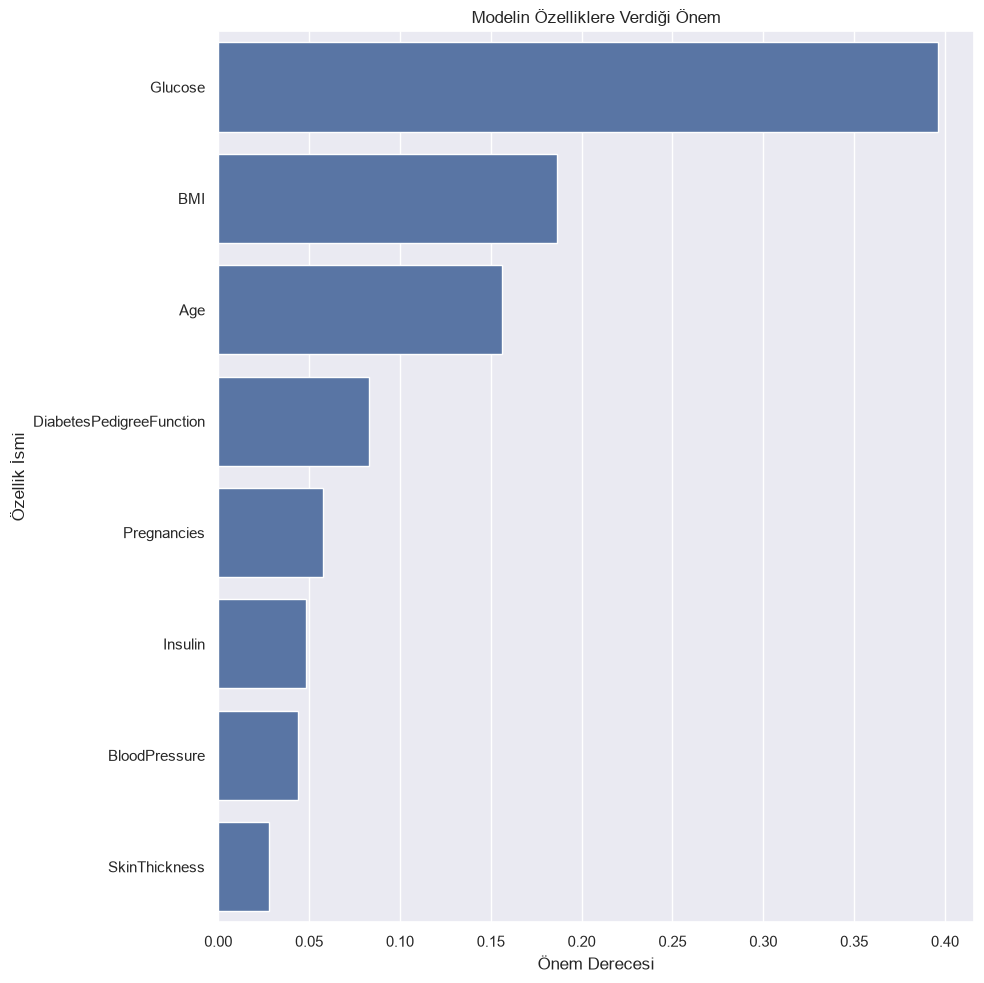

--------------------------------


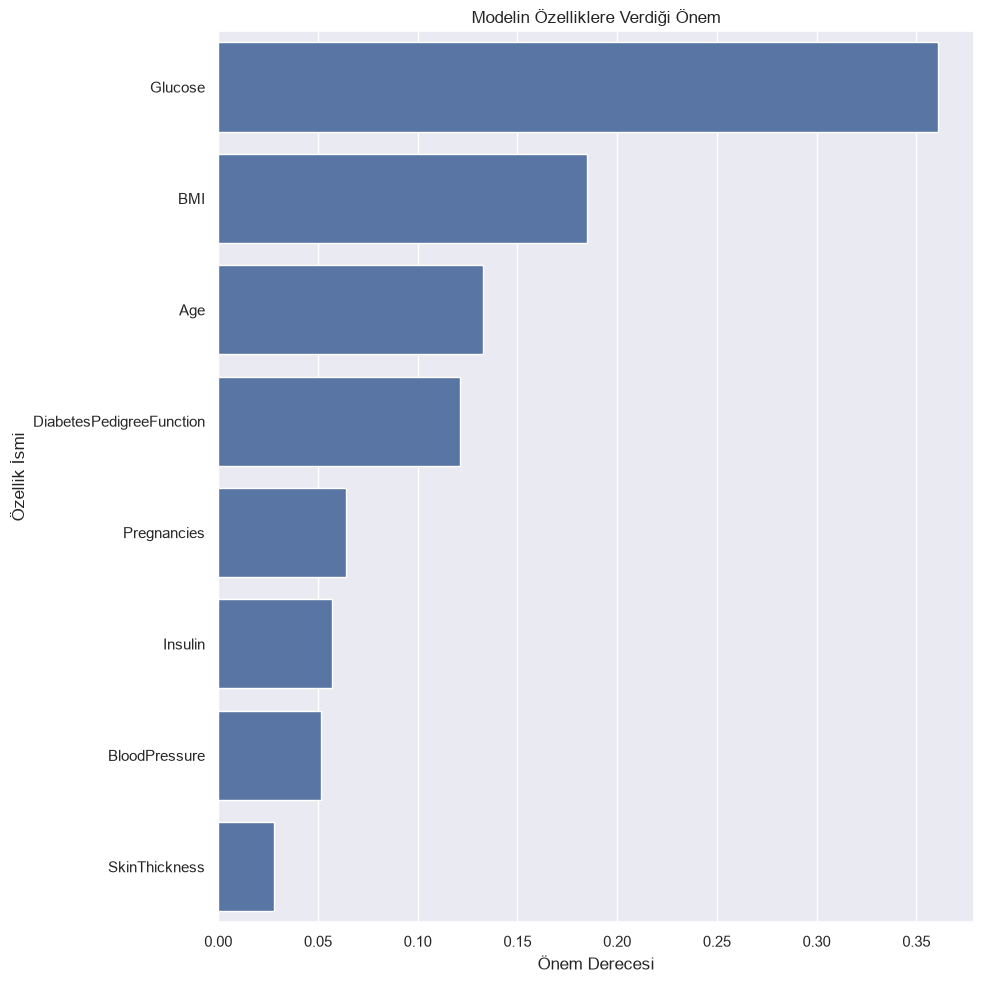

--------------------------------


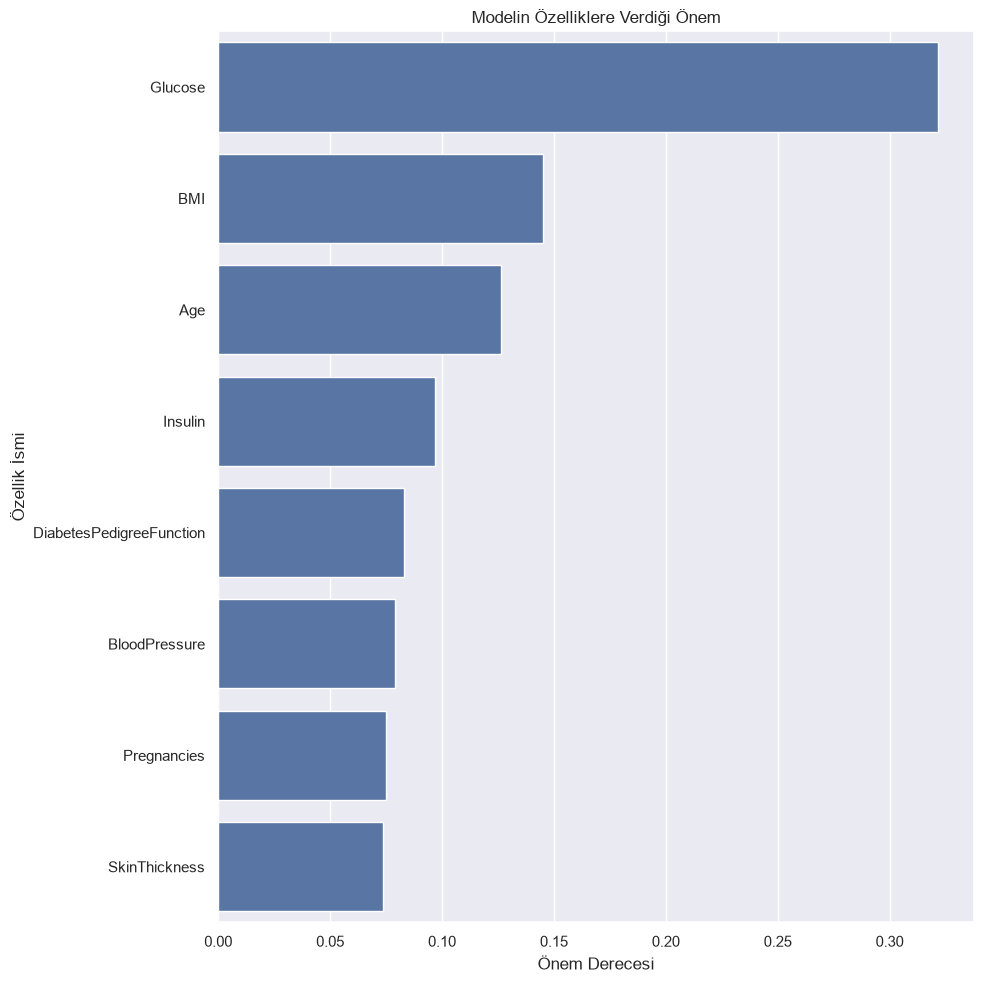

--------------------------------


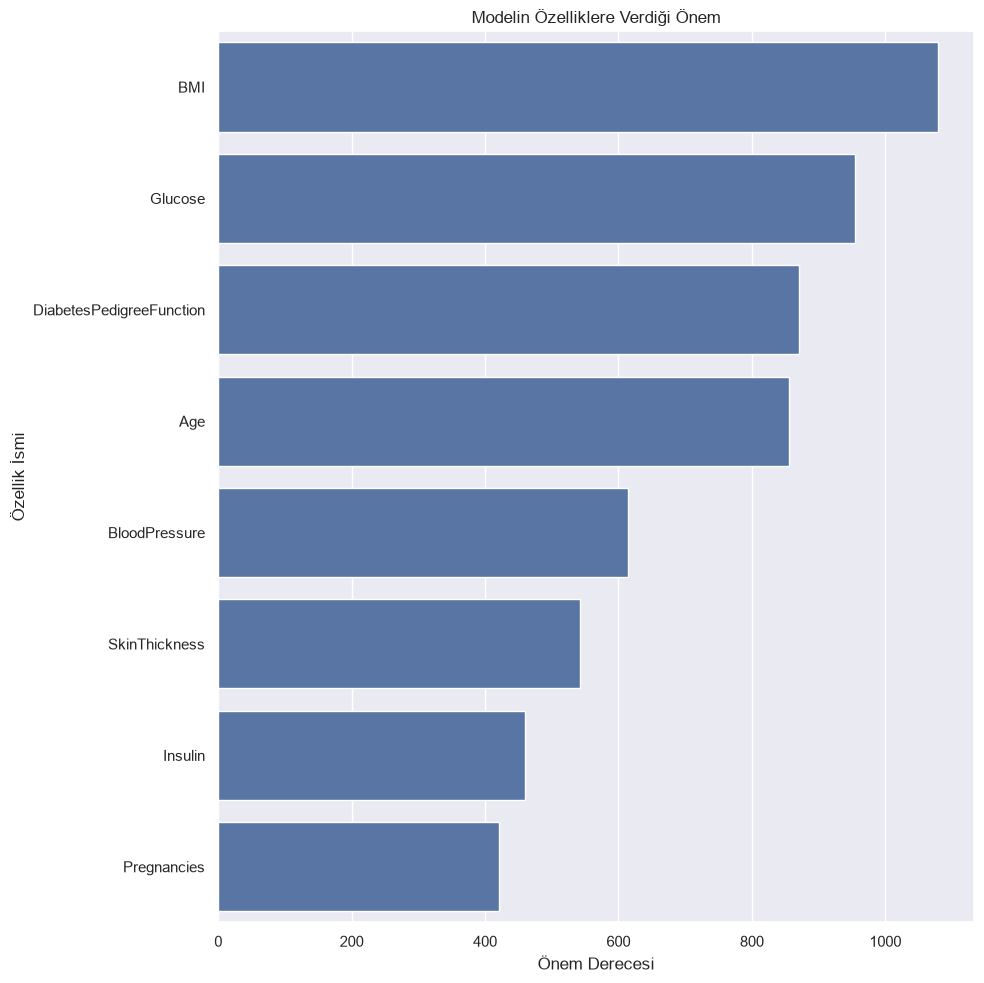

--------------------------------


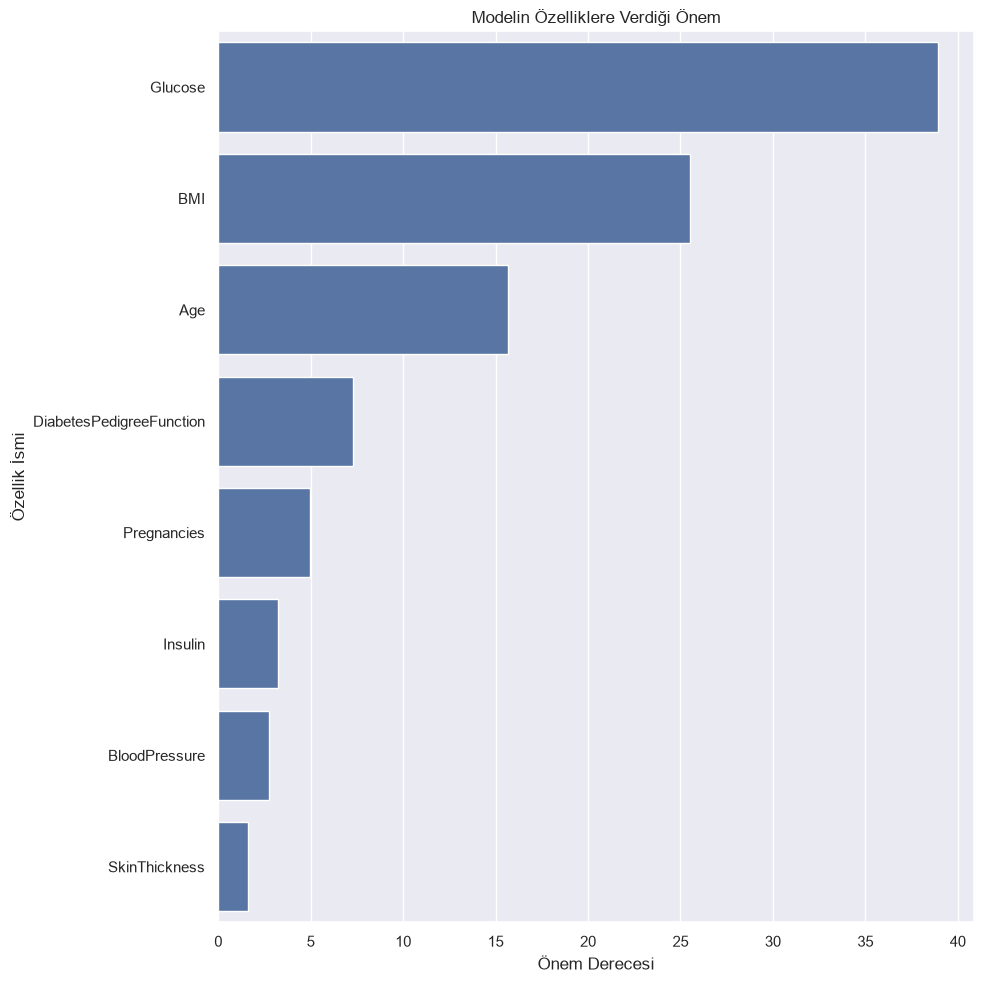

In [23]:
# Özellik Önemini Görselleştiren Fonksiyonu Sıfırdan Öğrenecek Biri İçin Açıklayalım

# Bu fonksiyon, modelin hangi değişkenlere (özelliklere) daha çok önem verdiğini görsel olarak göstermek için kullanılacak.
# "model": Tahmin (makine öğrenmesi) modelimizi buraya yazıyoruz.
# "features": Kullandığımız veri setindeki özellikler (X).
# "num": Kaç tane en önemli özelliği görmek istediğimizi belirtebiliriz (varsayılan: tümü).
# "save": Grafiği bilgisayara kaydetmek istersek True yapılabilir.
def plot_importance(model, features, num=len(X), save=False):
    # Modelin özellik önemlerini ve isimlerini bir tabloya kaydediyoruz.
    feature_imp = pd.DataFrame({'Önem Derecesi': model.feature_importances_, 'Özellik İsmi': features.columns})
    
    # Grafik boyutunu ayarlıyoruz (10x10).
    plt.figure(figsize=(10, 10))
    
    # Grafik stilini biraz büyütüyoruz ki yazılar okunaklı olsun.
    sns.set(font_scale=1)
    
    # En önemli özellikleri büyükten küçüğe sıralayıp çubuk grafikle çiziyoruz.
    sns.barplot(
        x="Önem Derecesi", 
        y="Özellik İsmi", 
        data=feature_imp.sort_values(by="Önem Derecesi", ascending=False)[0:num]
    )
    
    # Grafiğe başlık veriyoruz.
    plt.title('Modelin Özelliklere Verdiği Önem')
    plt.tight_layout()  # Grafik düzenini düzeltiyor.
    plt.show()  # Grafiği ekranda gösterir.
    
    # Eğer kullanıcı grafiği kaydetmek isterse, aşağıdaki kod çalışır.
    if save:
        plt.savefig('ozellik_onem_grafigi.png')

# Şimdi, her bir model için bu fonksiyonu çağırıyoruz ve böylece hangi model hangi özelliğe ne kadar önem veriyor kolayca görebiliyoruz.
plot_importance(rf_final, X)         # Random Forest modeli için
print("--------------------------------")
plot_importance(gbm_final, X)        # Gradient Boosting modeli için
print("--------------------------------")
plot_importance(xgboost_final, X)    # XGBoost modeli için
print("--------------------------------")
plot_importance(lgbm_final, X)       # LightGBM modeli için
print("--------------------------------")
plot_importance(catboost_final, X)   # CatBoost modeli için

### Hyperparameter Optimization with RandomSearchCV 

In [24]:
# 1. Öncelikle, kullanacağımız modelin tipini belirliyoruz. RandomForestClassifier, bir topluluk (ensemble) algoritmasıdır ve çoklu karar ağaçlarının çoğunluk oyuyla sınıflandırma yaptığı bir algoritmadır.
from sklearn.ensemble import RandomForestClassifier

# Modelimizi başlatıyoruz.
rf_model = RandomForestClassifier(random_state=17)

# 2. Modelin daha iyi sonuç vermesi için "hiperparametre" dediğimiz bazı ayarları denemek istiyoruz.
# Hiperparametreler, model eğitilmeden önce elle belirlenen ayarlardır.
# Burada deneyeceğimiz hiperparametreler:
# - 'max_depth': Bir ağacın maksimum derinliği (ağacın ne kadar dallanabileceği)
# - 'max_features': Her bölmede değerlendirilecek maksimum özellik sayısı
# - 'min_samples_split': Bir dalın ikiye ayrılabilmesi için gerekli minimum örnek sayısı
# - 'n_estimators': Ormanda kaç tane ağaç olacağı
import numpy as np

rf_random_params = {
    "max_depth": np.random.randint(5, 50, 10),                # 5 ile 50 arasında rastgele 10 tane derinlik
    "max_features": [3, 5, 7, "auto", "sqrt"],                # Özellik seçiminde farklı alternatifler
    "min_samples_split": np.random.randint(2, 50, 20),        # 2 ile 50 arasında rastgele 20 tane sayı
    "n_estimators": [int(x) for x in np.linspace(200, 1500, 10)]  # 200'den 1500'e kadar 10 farklı ağaç sayısı
}

# 3. Şimdi bu hiperparametrelerin en iyisini otomatik şekilde bulmak için RandomizedSearchCV adlı aracı kullanıyoruz.
from sklearn.model_selection import RandomizedSearchCV

# RandomizedSearchCV, belirttiğimiz parametre aralıklarında rastgele kombinasyonlar dener ve en iyisini bulmaya çalışır.
rf_random = RandomizedSearchCV(
    estimator=rf_model,                    # Hangi modeli kullanacağımızı söylüyoruz
    param_distributions=rf_random_params,  # Denenecek parametre aralıkları
    n_iter=100,                            # Toplamda rastgele 100 farklı kombinasyon dene
    cv=3,                                  # 3 katlı çapraz doğrulama ile değerlendirme yap
    verbose=True,                          # Eğitim sırasında detaylı bilgi ver
    random_state=42,                       # Sonuçların tekrarlanabilir olmasını sağlar
    n_jobs=-1                              # Bilgisayardaki tüm işlemcileri kullan
)

# 4. Arama işlemini başlatıyoruz; bütün parametre kombinasyonları model üzerinde denenecek.
rf_random.fit(X, y)  # Burada X öz niteliklerimizi, y ise hedef değişkenimizi ifade ediyor.

# 5. En iyi bulunan parametreleri görmek için:
print("En iyi hiperparametreler:", rf_random.best_params_)

# 6. Bu bulunan en iyi parametrelerle, modelimizi baştan tekrar kuruyoruz ve eğitiyoruz.
rf_random_final = rf_model.set_params(**rf_random.best_params_, random_state=17).fit(X, y)

# 7. Son olarak, optimize edilmiş modelimizin başarısını değerlendirmek için çapraz doğrulama ile üç farklı skor (accuracy, f1, roc_auc) kullanarak test ediyoruz.
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    rf_random_final, X, y, 
    cv=5,                               # 5 katlı doğrulama
    scoring=["accuracy", "f1", "roc_auc"]
)

# 8. Sonuçları ekrana yazdıralım
print("Accuracy (Doğruluk):", cv_results['test_accuracy'].mean())
print("F1 Skoru:", cv_results['test_f1'].mean())
print("ROC AUC Skoru:", cv_results['test_roc_auc'].mean())

Fitting 3 folds for each of 100 candidates, totalling 300 fits
En iyi hiperparametreler: {'n_estimators': 200, 'min_samples_split': np.int64(35), 'max_features': 'sqrt', 'max_depth': np.int64(43)}
Accuracy (Doğruluk): 0.7695866225277991
F1 Skoru: 0.6312952158258602
ROC AUC Skoru: 0.8373815513626834


#### Analyzing Model Complexity with Learning Curves

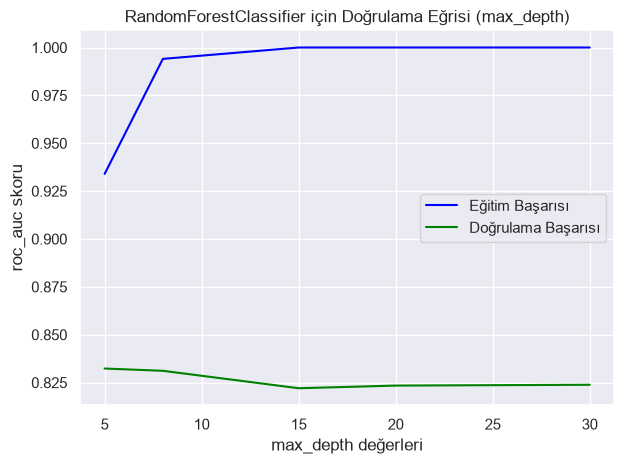

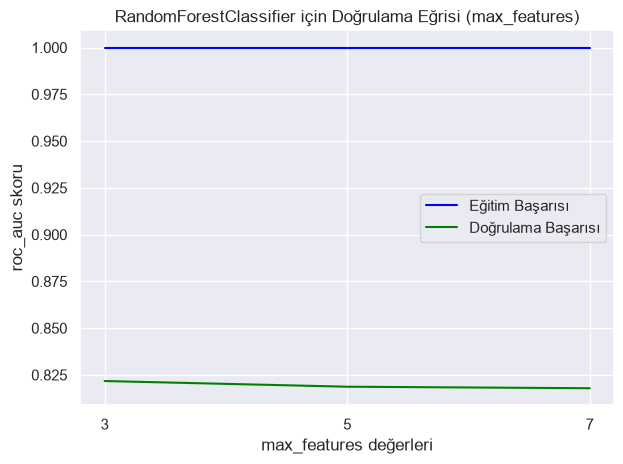

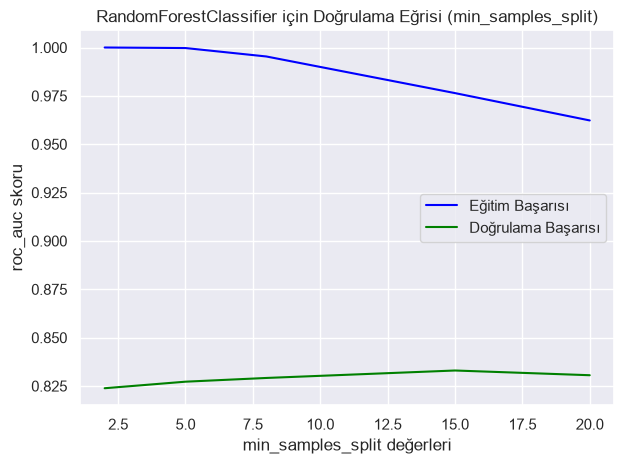

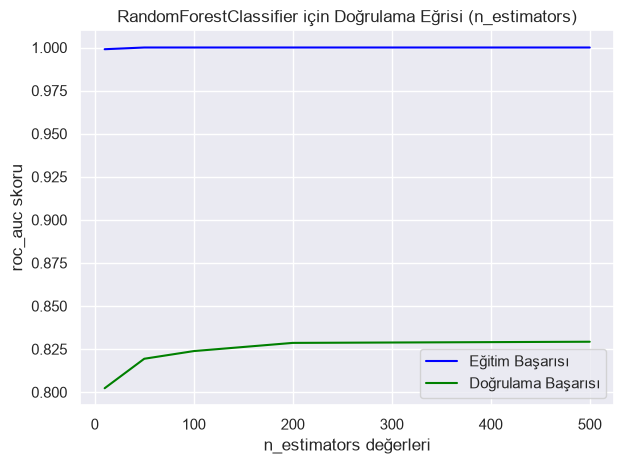

In [25]:
# Model Karmaşıklığını Öğrenme Eğrileriyle Analiz Etmek: Hiç Bilmeyene Açıklama

# Bu fonksiyon aşağıda ayrıntılı anlatılacak; amacı, bir makine öğrenmesi modelinde önemli parametrelerin değeri değiştikçe 
# modelin eğitim ve doğrulama başarılarının nasıl değiştiğini görselleştirmektir. 
# Yani, örneğin "ağaç derinliği artınca doğruluk nasıl değişiyor?" sorusuna yanıt ararız.

def val_curve_params(model, X, y, param_name, param_range, scoring="roc_auc", cv=10):
    """
    Amaç: Modelin belirli bir parametresinin farklı değerlerinde, eğitim setinde ve doğrulama setinde aldığı başarı skorlarını görmek.
    Parametreler:
      - model: Kullanmak istediğimiz makine öğrenmesi modeli (ör: RandomForestClassifier)
      - X: Özellikler (bağımsız değişkenler, tablonuzdaki sütunlar)
      - y: Hedef değişken (bağımlı değişken, sınıflar/etiketler)
      - param_name: İncelenecek parametre ismi (ör: max_depth, min_samples_split)
      - param_range: Denenecek parametre değerleri (ör: [1,2,3,4,5] gibi)
      - scoring: Başarı metriği (örn: doğruluk, f1, roc_auc)
      - cv: Kaç parçalı çapraz doğrulama yapılacak (varsayılan 10)
    """

    # validation_curve fonksiyonu, modeli parametre değerleri farklı farklı ayarlayarak hem eğitimde (train) hem de doğrulamada (test) puanlar hesaplar.
    # Böylece, model belirli bir parametre değerinde aşırı öğreniyor mu (overfit) yoksa yetersiz mi öğreniyor (underfit) görebiliriz.
    train_score, test_score = validation_curve(
        model, X=X, y=y, param_name=param_name, param_range=param_range, scoring=scoring, cv=cv)

    # Her parametre değeri için ortalama eğitim ve doğrulama skorlarını aldık.
    mean_train_score = np.mean(train_score, axis=1)
    mean_test_score = np.mean(test_score, axis=1)

    # Şimdi puanları çizdiriyoruz.
    plt.plot(param_range, mean_train_score, label="Eğitim Başarısı", color='blue')
    plt.plot(param_range, mean_test_score, label="Doğrulama Başarısı", color='green')
    plt.title(f"{type(model).__name__} için Doğrulama Eğrisi ({param_name})")
    plt.xlabel(f"{param_name} değerleri")
    plt.ylabel(f"{scoring} skoru")
    plt.tight_layout()
    plt.legend(loc='best')
    plt.show(block=True)

# Şimdi hangi parametreleri inceleyeceğimizin listesini hazırlıyoruz. 
# Her biri için ([parametre adı], [denenecek değerler]) şeklinde bir liste yaratıyoruz.
rf_val_params = [
    ["max_depth", [5, 8, 15, 20, 30, None]],      # Ağacın maksimum derinliği
    ["max_features", [3, 5, 7, "auto"]],          # Her ağaç için kullanılan özellik (bağımsız değişken) sayısı
    ["min_samples_split", [2, 5, 8, 15, 20]],     # Bir düğümün bölünebilmesi için gereken minimum örnek sayısı
    ["n_estimators", [10, 50, 100, 200, 500]]     # Toplam oluşturulacak ağaç sayısı
]

# Bir Random Forest (Rastgele Orman) modeli oluşturuyoruz.
rf_model = RandomForestClassifier(random_state=17)

# Her parametre için, yukarıdaki fonksiyonu çalıştırıyoruz. Yani parametreyi değiştirerek modelin başarısını görselleştiriyoruz.
for param in rf_val_params:
    val_curve_params(rf_model, X, y, param[0], param[1])

# Örneğin kullanımı: 
# Yukarıdaki kodda ["max_depth", [5, 8, 15, 20, 30, None]] parametresi için 
# farklı derinliklerde modelin başarısını görebilirsiniz.
